### Biblioteki

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import ParameterGrid

In [2]:
from src.models.load_data import split_data, create_dataloader, create_dataset, get_sampler
from src.utils.load_data import load_data
from src.models.models import SimpleGRUClassifier, GRUClassifier
from src.music_dataset.MusicDataset import MusicDataset
from src.models.train_model import train_model
from src.models.evaluate import evaluate_model
from src.models.predict import predict, save_predictions

### Zmienn globalne

In [3]:
TRAIN_PATH = "data/train.pkl"
TEST_PATH = "data/test_no_target.pkl"
BOUNDRY = 1024
PAD_VALUE = 0

### Device

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Podział danych

In [17]:
train_data = load_data(TRAIN_PATH)

In [18]:
x_train, y_train, x_val, y_val, x_test, y_test = split_data(train_data, train_ratio=0.75)

train_dataset = create_dataset(x_train, y_train, BOUNDRY, PAD_VALUE, if_embedding=False)
val_dataset = create_dataset(x_val, y_val, BOUNDRY, PAD_VALUE, if_embedding=False)
test_dataset = create_dataset(x_test, y_test, BOUNDRY, PAD_VALUE, if_embedding=False)


train_dataset_emb = create_dataset(x_train, y_train, BOUNDRY, PAD_VALUE)
val_dataset_emb = create_dataset(x_val, y_val, BOUNDRY, PAD_VALUE)
test_dataset_emb = create_dataset(x_test, y_test, BOUNDRY, PAD_VALUE)


In [19]:
train_sampler = get_sampler(train_dataset)
val_sampler = get_sampler(val_dataset)
test_sampler = get_sampler(test_dataset)

train_dataloader = create_dataloader(train_dataset, batch_size=32, sampler=train_sampler)
val_dataloader = create_dataloader(val_dataset, batch_size=32, sampler=val_sampler)
test_dataloader = create_dataloader(test_dataset, batch_size=32, sampler=test_sampler)

train_dataloader_emb = create_dataloader(train_dataset_emb, batch_size=32, sampler=train_sampler)
val_dataloader_emb = create_dataloader(val_dataset_emb, batch_size=32, sampler=val_sampler)
test_dataloader_emb = create_dataloader(test_dataset_emb, batch_size=32, sampler=test_sampler)

In [20]:
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"\nTrain dataloader size: {len(train_dataloader)}")
print(f"Validation dataloader size: {len(val_dataloader)}")
print(f"Test dataloader size: {len(test_dataloader)}")

Train dataset size: 1653
Validation dataset size: 551
Test dataset size: 735

Train dataloader size: 52
Validation dataloader size: 18
Test dataloader size: 23


### Wagi klas

In [21]:
classes = [c[1].item() for c in train_dataset.samples]
class_counts = Counter(classes)
num_classes = len(class_counts)
total_count = sum(class_counts.values())

# Compute inverse frequency weights and normalize by number of classes
class_weights = {cls: total_count / (num_classes * count) for cls, count in class_counts.items()}
class_weights_tensor = torch.tensor(list(class_weights.values()), dtype=torch.float32, device=device)

print(f"Class weights: {class_weights_tensor}")

Class weights: tensor([0.3609, 1.3331, 1.2290, 3.8000, 2.4857], device='cuda:0')


### Prosty Model GRU

In [11]:
simple_model = SimpleGRUClassifier(input_size=1, hidden_size=128, output_size=5, num_layers=2, dropout=0.3).to(device)
simple_optimizer = optim.Adam(simple_model.parameters(), lr=0.001)
simple_criterion = nn.CrossEntropyLoss()

c:\Users\barte\OneDrive\Pulpit\SEMESTR 6\.venv_2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
train_model(simple_model, simple_criterion, simple_optimizer, 50, train_dataloader, val_dataloader, device)

Validation: 100%|██████████| 18/18 [00:00<00:00, 48.95it/s]


Epoch 1: Train Loss: 1.3132 | Train Acc: 0.5172 | Val Loss: 1.2060 | Val Acc: 0.5862


Validation: 100%|██████████| 18/18 [00:00<00:00, 54.65it/s]


Epoch 2: Train Loss: 1.1990 | Train Acc: 0.5802 | Val Loss: 1.1095 | Val Acc: 0.6007


Validation: 100%|██████████| 18/18 [00:00<00:00, 53.32it/s]


...

Epoch 48: Train Loss: 0.0641 | Train Acc: 0.9819 | Val Loss: 1.0723 | Val Acc: 0.7713


Validation: 100%|██████████| 18/18 [00:00<00:00, 51.04it/s]


Epoch 49: Train Loss: 0.1031 | Train Acc: 0.9649 | Val Loss: 1.1023 | Val Acc: 0.7477


Validation: 100%|██████████| 18/18 [00:00<00:00, 49.28it/s]

Epoch 50: Train Loss: 0.0738 | Train Acc: 0.9776 | Val Loss: 1.2782 | Val Acc: 0.7441


In [ ]:
class_acc, mean_acc = evaluate_model(simple_model, val_dataloader, device)

Testing: 100%|██████████| 18/18 [00:00<00:00, 25.66it/s]

Accuracy per class:
Class 0: 0.8908
Class 1: 0.5361
Class 2: 0.1724
Class 3: 0.5333
Class 4: 0.7619

Mean Accuracy: 0.5789
Validation Class Accuracy: {0: 0.8907849829351536, 1: 0.5360824742268041, 2: 0.1724137931034483, 3: 0.5333333333333333, 4: 0.7619047619047619}
Validation Mean Accuracy: 0.5789038691007002


#### Dodanie wag klas

In [16]:
simple_model = SimpleGRUClassifier(input_size=1, hidden_size=128, output_size=5, num_layers=2, dropout=0.3).to(device)
simple_optimizer = optim.Adam(simple_model.parameters(), lr=0.001)
simple_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

In [17]:
train_model(simple_model, simple_criterion, simple_optimizer, 50, train_dataloader, val_dataloader, device)

Validation: 100%|██████████| 18/18 [00:00<00:00, 50.92it/s]


Epoch 1: Train Loss: 1.4361 | Train Acc: 0.2662 | Val Loss: 1.2602 | Val Acc: 0.1779


Validation: 100%|██████████| 18/18 [00:00<00:00, 49.50it/s]


Epoch 2: Train Loss: 1.3176 | Train Acc: 0.2880 | Val Loss: 1.2971 | Val Acc: 0.2613


Validation: 100%|██████████| 18/18 [00:00<00:00, 49.65it/s]


...

Epoch 48: Train Loss: 0.1180 | Train Acc: 0.9214 | Val Loss: 1.0844 | Val Acc: 0.8004


Validation: 100%|██████████| 18/18 [00:00<00:00, 47.38it/s]


Epoch 49: Train Loss: 0.0792 | Train Acc: 0.9522 | Val Loss: 1.3726 | Val Acc: 0.7623


Validation: 100%|██████████| 18/18 [00:00<00:00, 52.02it/s]

Epoch 50: Train Loss: 0.0735 | Train Acc: 0.9552 | Val Loss: 1.1235 | Val Acc: 0.7405


In [29]:
acc, mean_acc = evaluate_model(simple_model, val_dataloader, device)

Testing: 100%|██████████| 18/18 [00:00<00:00, 26.64it/s]

Accuracy per class:
Class 0: 0.8102
Class 1: 0.6967
Class 2: 0.5217
Class 3: 0.7183
Class 4: 0.8000

Mean Accuracy: 0.7094


**Dodanie wag do klas sprawia, wzrost średniego accuracy**

### GRU z Embeddingami

In [23]:
NUM_ACCORDS = 194
EMBEDDING_DIM=32
HIDDEN_SIZE=128
OUTPUT_SIZE=5
NUM_LAYERS=2
DROPOUT=0.3
BIDIRECTIONAL=True

In [24]:
model = GRUClassifier(num_acords=NUM_ACCORDS, embedding_dim=EMBEDDING_DIM, hidden_size=HIDDEN_SIZE, output_size=OUTPUT_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT, bidirectional=BIDIRECTIONAL).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [26]:
train_model(model=model, criterion=criterion, optimizer=optimizer, epochs=20, train_dataloader=train_dataloader_emb, val_dataloader=val_dataloader_emb, device=device)

Validation: 100%|██████████| 18/18 [00:00<00:00, 46.69it/s]


Epoch 1: Train Loss: 0.7854 | Train Acc: 0.7302 | Val Loss: 0.9315 | Val Acc: 0.7060


Validation: 100%|██████████| 18/18 [00:00<00:00, 48.63it/s]


Epoch 2: Train Loss: 0.5629 | Train Acc: 0.8191 | Val Loss: 0.5491 | Val Acc: 0.8131


Validation: 100%|██████████| 18/18 [00:00<00:00, 43.14it/s]


...

Epoch 18: Train Loss: 0.0885 | Train Acc: 0.9704 | Val Loss: 0.4096 | Val Acc: 0.9056


Validation: 100%|██████████| 18/18 [00:00<00:00, 47.22it/s]


Epoch 19: Train Loss: 0.0541 | Train Acc: 0.9794 | Val Loss: 0.2440 | Val Acc: 0.9129


Validation: 100%|██████████| 18/18 [00:00<00:00, 47.59it/s]

Epoch 20: Train Loss: 0.0766 | Train Acc: 0.9728 | Val Loss: 0.3316 | Val Acc: 0.9183


In [28]:
acc, mean_acc = evaluate_model(model=model, test_dataloader=test_dataloader, device=device)

Testing: 100%|██████████| 23/23 [00:00<00:00, 27.39it/s]

Accuracy per class:
Class 0: 0.9565
Class 1: 0.8559
Class 2: 0.7500
Class 3: 0.7168
Class 4: 1.0000

Mean Accuracy: 0.8559


#### Dodanie wag do klas

In [30]:
model = GRUClassifier(num_acords=NUM_ACCORDS, embedding_dim=EMBEDDING_DIM, hidden_size=HIDDEN_SIZE, output_size=OUTPUT_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT, bidirectional=BIDIRECTIONAL).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [31]:
train_model(model=model, criterion=criterion, optimizer=optimizer, epochs=20, train_dataloader=train_dataloader_emb, val_dataloader=val_dataloader_emb, device=device)

Validation: 100%|██████████| 18/18 [00:00<00:00, 48.04it/s]


Epoch 1: Train Loss: 1.2684 | Train Acc: 0.3479 | Val Loss: 1.0727 | Val Acc: 0.5045


Validation: 100%|██████████| 18/18 [00:00<00:00, 54.02it/s]


Epoch 2: Train Loss: 0.7651 | Train Acc: 0.5826 | Val Loss: 0.7003 | Val Acc: 0.6806


Validation: 100%|██████████| 18/18 [00:00<00:00, 46.38it/s]


...

Epoch 18: Train Loss: 0.0960 | Train Acc: 0.9540 | Val Loss: 0.2234 | Val Acc: 0.9129


Validation: 100%|██████████| 18/18 [00:00<00:00, 52.17it/s]


Epoch 19: Train Loss: 0.0735 | Train Acc: 0.9691 | Val Loss: 0.2155 | Val Acc: 0.8929


Validation: 100%|██████████| 18/18 [00:00<00:00, 50.03it/s]

Epoch 20: Train Loss: 0.0755 | Train Acc: 0.9637 | Val Loss: 0.3350 | Val Acc: 0.8911


In [32]:
acc, mean_acc = evaluate_model(model=model, test_dataloader=test_dataloader, device=device)

Testing: 100%|██████████| 23/23 [00:00<00:00, 28.50it/s]

Accuracy per class:
Class 0: 0.9157
Class 1: 0.8898
Class 2: 0.7436
Class 3: 0.8351
Class 4: 0.9825

Mean Accuracy: 0.8733


**Dodanie wag do klas przy użyciu embeddingów, w lekkim stopniu poprawia średnie accuracy**<br>
**Najgorzej jest rozpoznawana najmniej liczna klasa**

### Dostrajanie parametrów

In [20]:
# seed
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)


In [29]:
set_seed(42)

In [ ]:
NUM_ACCORDS = 194
OUTPUT_SIZE = 5
LAYERS = [3, 4]
HIDDEN_SIZES = [64, 128]
EMBEDDING_DIMS = [16, 32, 64]
DROPOUT = [0.1, 0.2, 0.3]

results = []

current_best_acc = 0.0

parameter_grid = ParameterGrid(
    {
        'num_layers': LAYERS,
        'hidden_size': HIDDEN_SIZES,
        'embedding_dim': EMBEDDING_DIMS,
        'dropout': DROPOUT,
        'bidirectional': [True, False]
    }
)

for params in parameter_grid:
    print("Evaluating parameters:", params)
    model = GRUClassifier(
        num_acords=NUM_ACCORDS,
        embedding_dim=params['embedding_dim'],
        hidden_size=params['hidden_size'],
        output_size=OUTPUT_SIZE,
        num_layers=params['num_layers'],
        dropout=params['dropout'],
        bidirectional=params['bidirectional']
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    train_model(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        epochs=20,
        train_dataloader=train_dataloader_emb,
        val_dataloader=val_dataloader_emb,
        device=device,
        verbose=False
    )


    _, mean_acc = evaluate_model(model=model, test_dataloader=test_dataloader, device=device, verbose=False)
    if mean_acc > current_best_acc:
        current_best_acc = mean_acc
        # saving model
        print("New best model found, saving...")
        torch.save(model.state_dict(), f"best_model.pth")

    results.append((params, mean_acc))
    print(f"Parameters: {params} - Mean Accuracy: {mean_acc:.4f}\n")

best = max(results, key=lambda x: x[1])
print("Best parameters:", best[0], "with mean accuracy:", best[1])

Evaluating parameters: {'bidirectional': True, 'dropout': 0.1, 'embedding_dim': 16, 'hidden_size': 64, 'num_layers': 3}


Testing: 100%|██████████| 23/23 [00:00<00:00, 66.24it/s]   


New best model found, saving...
Parameters: {'bidirectional': True, 'dropout': 0.1, 'embedding_dim': 16, 'hidden_size': 64, 'num_layers': 3} - Mean Accuracy: 0.8687

Evaluating parameters: {'bidirectional': True, 'dropout': 0.1, 'embedding_dim': 16, 'hidden_size': 64, 'num_layers': 4}


Testing: 100%|██████████| 23/23 [00:00<00:00, 49.80it/s]   


Parameters: {'bidirectional': True, 'dropout': 0.1, 'embedding_dim': 16, 'hidden_size': 64, 'num_layers': 4} - Mean Accuracy: 0.8201

Evaluating parameters: {'bidirectional': True, 'dropout': 0.1, 'embedding_dim': 16, 'hidden_size': 128, 'num_layers': 3}


...

Parameters: {'bidirectional': False, 'dropout': 0.3, 'embedding_dim': 64, 'hidden_size': 64, 'num_layers': 4} - Mean Accuracy: 0.8671

Evaluating parameters: {'bidirectional': False, 'dropout': 0.3, 'embedding_dim': 64, 'hidden_size': 128, 'num_layers': 3}


Testing: 100%|██████████| 23/23 [00:00<00:00, 56.70it/s]   


Parameters: {'bidirectional': False, 'dropout': 0.3, 'embedding_dim': 64, 'hidden_size': 128, 'num_layers': 3} - Mean Accuracy: 0.8945

Evaluating parameters: {'bidirectional': False, 'dropout': 0.3, 'embedding_dim': 64, 'hidden_size': 128, 'num_layers': 4}


Testing: 100%|██████████| 23/23 [00:00<00:00, 44.80it/s]   

Parameters: {'bidirectional': False, 'dropout': 0.3, 'embedding_dim': 64, 'hidden_size': 128, 'num_layers': 4} - Mean Accuracy: 0.8390

Best parameters: {'bidirectional': False, 'dropout': 0.1, 'embedding_dim': 64, 'hidden_size': 64, 'num_layers': 3} with mean accuracy: 0.9223508835796972


### Predyckje

In [6]:
evaluate_set = load_data(TEST_PATH)

evaluate_dataset = MusicDataset(evaluate_set, BOUNDRY, PAD_VALUE, if_embedding=True, has_label=False)
evaluate_dataloader = create_dataloader(evaluate_dataset, batch_size=32)


In [24]:
NUM_ACCORDS = 194
OUTPUT_SIZE = 5

best_model = GRUClassifier(
    num_acords=NUM_ACCORDS,
    embedding_dim=64,
    hidden_size=64,
    output_size=OUTPUT_SIZE,
    num_layers=3,
    dropout=0.1,
    bidirectional=False
).to(device)

best_model.load_state_dict(torch.load("best_model.pth"))

predictions = predict(best_model, evaluate_dataloader, device)



#### Rozkład predykcji

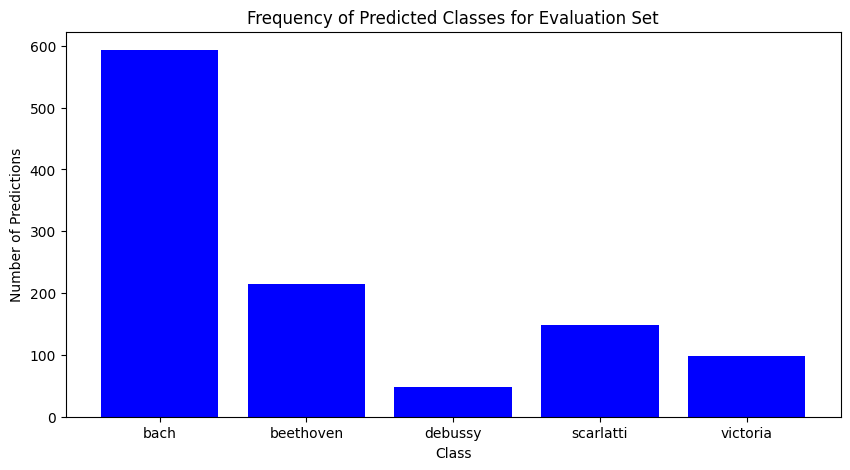

In [25]:
prediction_counts = Counter(predictions)

MAP = {0: 'bach', 1: 'beethoven', 2: 'debussy', 3: 'scarlatti', 4: 'victoria'}

class_indices = [MAP[i] for i in range(len(prediction_counts))]
counts = [prediction_counts[i] for i in range(len(prediction_counts))]

plt.figure(figsize=(10, 5))
plt.bar(class_indices, counts, color='blue')
plt.xlabel('Class')
plt.ylabel('Number of Predictions')
plt.title('Frequency of Predicted Classes for Evaluation Set')
plt.show()

In [27]:
save_predictions(predictions, "pred.csv")

Predictions saved to pred.csv


#### Sprawdzenie innego modelu

In [22]:
params = {'bidirectional': True, 'dropout': 0.2, 'embedding_dim': 64, 'hidden_size': 128, 'num_layers': 3}

different_model = GRUClassifier(
    num_acords=NUM_ACCORDS,
    embedding_dim=params['embedding_dim'],
    hidden_size=params['hidden_size'],
    output_size=OUTPUT_SIZE,
    num_layers=params['num_layers'],
    dropout=params['dropout'],
    bidirectional=params['bidirectional']
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(different_model.parameters(), lr=0.001)

train_model(
    model=different_model,
    criterion=criterion,
    optimizer=optimizer,
    epochs=20,
    train_dataloader=train_dataloader_emb,
    val_dataloader=val_dataloader_emb,
    device=device
)

evaluate_model(model=different_model, test_dataloader=test_dataloader_emb, device=device)

c:\Users\barte\OneDrive\Pulpit\SEMESTR 6\.venv_2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 1: Train Loss: 1.1824 | Train Acc: 0.3485 | Val Loss: 0.8458 | Val Acc: 0.5953


Epoch 2: Train Loss: 0.6355 | Train Acc: 0.6140 | Val Loss: 0.4596 | Val Acc: 0.7604


Epoch 3: Train Loss: 0.5428 | Train Acc: 0.7586 | Val Loss: 0.4801 | Val Acc: 0.7786


Epoch 4: Train Loss: 0.3782 | Train Acc: 0.8379 | Val Loss: 0.4420 | Val Acc: 0.7550


...

Epoch 19: Train Loss: 0.0566 | Train Acc: 0.9770 | Val Loss: 0.3873 | Val Acc: 0.9056


Epoch 20: Train Loss: 0.0328 | Train Acc: 0.9879 | Val Loss: 0.4300 | Val Acc: 0.9347


Testing: 100%|██████████| 23/23 [00:00<00:00, 29.03it/s]

Accuracy per class (%):
Class 0: 97.47%
Class 1: 88.46%
Class 2: 78.05%
Class 3: 84.55%
Class 4: 92.96%

Mean Accuracy: 88.30%


({0: 0.9747474747474747,
  1: 0.8846153846153846,
  2: 0.7804878048780488,
  3: 0.8455284552845529,
  4: 0.9295774647887324},
 0.8829913168628387)

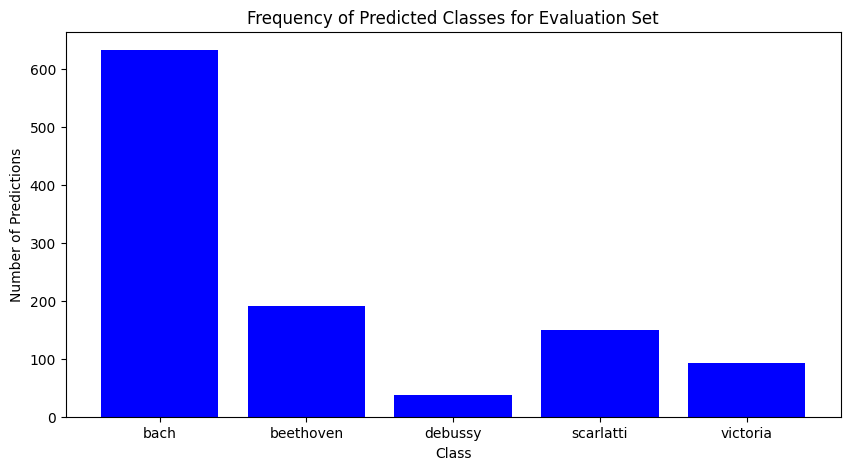

In [23]:
predictions = predict(different_model, evaluate_dataloader, device)

prediction_counts = Counter(predictions)

MAP = {0: 'bach', 1: 'beethoven', 2: 'debussy', 3: 'scarlatti', 4: 'victoria'}

class_indices = [MAP[i] for i in range(len(prediction_counts))]
counts = [prediction_counts[i] for i in range(len(prediction_counts))]

plt.figure(figsize=(10, 5))
plt.bar(class_indices, counts, color='blue')
plt.xlabel('Class')
plt.ylabel('Number of Predictions')
plt.title('Frequency of Predicted Classes for Evaluation Set')
plt.show()

**Rokzłady predykowanych klas różnych modeli są bardzo podobnie i zbliżone do rozkładu klas w zestawie treningowym**